# Import Required Libraries

Import necessary libraries such as NumPy, PIL, Torch, and the FPIInference model.

In [8]:
import numpy as np
import torch
from PIL import Image
import matplotlib.pyplot as plt
# Import the FPIInference model
from fpi_model import FPIInference

c:\Users\roman\miniconda3\envs\geoloc2\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
import distill.taskflow as taskflow
import argparse
import os
from distill.configuration_file import config
from pathlib import Path

In [14]:
config_path = r'distill\new_example_config.json'

# Load the Model from fpi_model

Load the pre-trained FPI model using the FPIInference class. You need to provide paths to the config and checkpoint files.

In [15]:
config(config_path)

In [20]:
from fpi_model import load_checkpoint

In [ ]:
# Paths to config and checkpoint (adjust as needed)
config_path = r'distill\new_example_config.json'
checkpoint_path = 'net_best.pth'  # Path to the trained model checkpoint

# Device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Initialize the model
fpi_model = FPIInference(config_path, checkpoint_path, device=device)
load_checkpoint(fpi_model.model, checkpoint_path, device)
print("Model loaded successfully!")

Load pretrained backbone checkpoint from: checkpoints/CvT-13-384x384-IN-22k.pth
missing keys: []
unexpected keys: ['head.weight', 'head.bias']
Load pretrained backbone checkpoint from: checkpoints/CvT-13-384x384-IN-22k.pth
missing keys: []
unexpected keys: ['head.weight', 'head.bias']
Model loaded successfully!


# Prepare Input Data

Load UAV and satellite images. For demonstration, we'll use placeholder images or load from files.

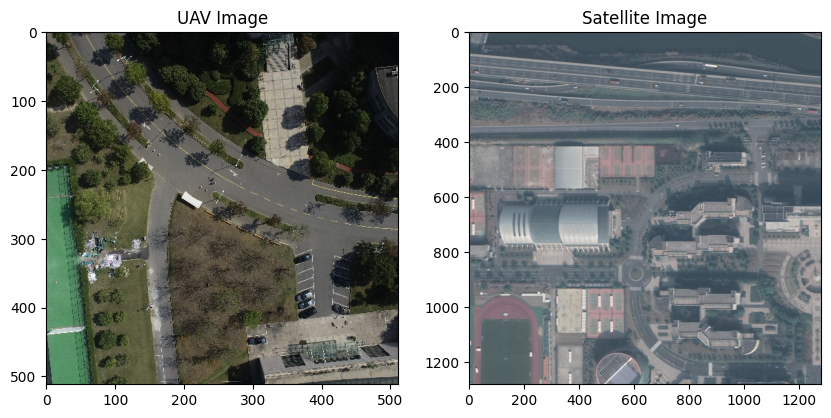

In [25]:
# For demonstration, load sample images
# Replace with actual paths to UAV and satellite images
uav_image_path = r'map2019\train\Caijing_000000\UAV\0.JPG'  # Example path
satellite_image_path = r'map2019\train\Caijing_000000\Satellite\0.tif'  # Example path

# Load images
uav_image = Image.open(uav_image_path)
satellite_image = Image.open(satellite_image_path)

# Display images
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(uav_image)
plt.title('UAV Image')
plt.subplot(1, 2, 2)
plt.imshow(satellite_image)
plt.title('Satellite Image')
plt.show()

# Run Model Inference

Use the loaded model to predict the pixel coordinates on the satellite image corresponding to the UAV image.

In [26]:
# Run prediction
result = fpi_model.predict(uav_image, satellite_image, return_heatmap=True)

# Extract results
pixel_coord = result['pixel_coordinate']
pixel_norm = result['pixel_normalized']
heatmap = result['heatmap']

print(f"Predicted pixel coordinate: {pixel_coord}")
print(f"Normalized coordinate: {pixel_norm}")

Predicted pixel coordinate: (0, 32)
Normalized coordinate: (0.0, 0.05555555555555555)


# Display and Analyze Results

Visualize the heatmap overlay on the satellite image and analyze the prediction.

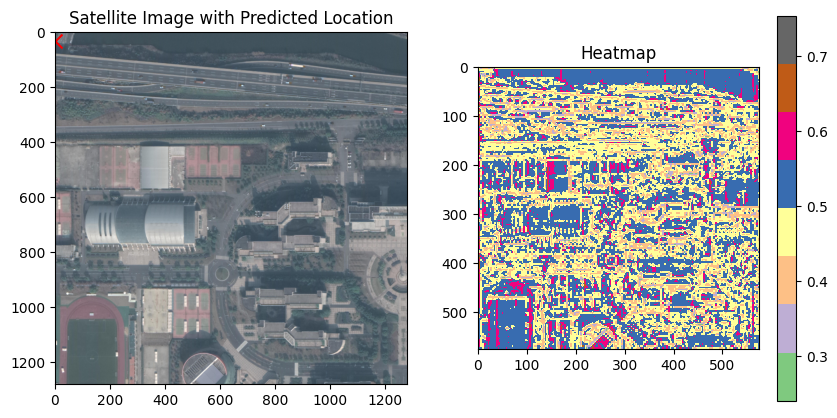

Analysis: The red X marks the predicted location of the UAV object on the satellite image.


In [27]:
# Visualize the heatmap
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(satellite_image)
plt.scatter(pixel_coord[0], pixel_coord[1], color='red', s=100, marker='x')
plt.title('Satellite Image with Predicted Location')

plt.subplot(1, 2, 2)
plt.imshow(heatmap, cmap='Accent')
plt.title('Heatmap')
plt.colorbar()
plt.show()

# Additional analysis
print("Analysis: The red X marks the predicted location of the UAV object on the satellite image.")

Да работает херово, но автор прикрепил походу только часть весов 🤡🤡🤡, так что если Блек выделит компьют, то возможно что-то получится

In [9]:
mod=torch.load(r'D:\CrossGeoLoc_clear_version\for_us\checkpoints\CvT-13-384x384-IN-22k.pth',map_location='cpu')

In [10]:
mod['head.weight'].shape

torch.Size([1000, 384])

In [12]:
config(config_path).__dict__.items()

dict_items([('model', {'backbone': {'type': 'CvT', 'vit_type': 'cvt13', 'pretrain_path': 'checkpoints/CvT-13-384x384-IN-22k.pth', 'pretrain': True, 'output_index': [0, 1, 2]}, 'neck': {'type': 'CCN', 'output_dims': 384, 'UAV_output_index': [0], 'Satellite_ouput_index': 0}, 'head': {'type': 'ChannelEmbedding', 'input_ndim': 384, 'mid_process_channels': [64, 16, 1]}, 'postprocess': {'upsample_to_original': True, 'upsample_method': 'NearstUpsample', 'output_size': [576, 576]}, 'loss': {'cls_loss': {'type': 'BalanceLoss', 'center_R': 31, 'neg_weight': 130}}}), ('data_config', {'batchsize': 8, 'num_worker': 0, 'val_batchsize': 8, 'train_dir': 'D:/CrossGeoLoc_clear_version/map2019/train', 'val_dir': 'D:/CrossGeoLoc_clear_version/map2019/val', 'test_dir': 'D:/CrossGeoLoc_clear_version/map2019/train', 'test_mode': 'merge_test_700-1800_cr0.95_stride100', 'UAVhw': [192, 192], 'Satellitehw': [576, 576]}), ('pipline_config', {'train_pipeline': {'UAV': {'RandomErasing': {'probability': 0.3}, 'Rando

In [1]:
import torch

In [6]:
torch.load("net_best.pth")

C:\Users\roman\AppData\Local\Temp\ipykernel_22132\3683886234.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("net_best.pth")


OrderedDict([('union_backbone.backbone.backbone.stage0.patch_embed.proj.weight',
              tensor([[[[-3.9158e-02, -2.5615e-02, -5.8755e-02,  ...,  1.9723e-02,
                          2.5567e-02,  3.4043e-02],
                        [-7.2480e-02, -8.4901e-02, -1.2948e-01,  ...,  1.8626e-02,
                          4.0742e-02,  1.3160e-01],
                        [-1.4501e-01, -1.4451e-01, -3.0919e-01,  ...,  3.3167e-01,
                         -1.4730e-02,  1.1157e-01],
                        ...,
                        [-1.4048e-01, -1.8004e-01,  1.3689e-01,  ..., -1.5488e-01,
                          1.6048e-01,  7.8125e-02],
                        [-1.1714e-01, -1.2649e-01,  4.8652e-02,  ...,  9.1084e-02,
                          1.8262e-01,  6.7776e-02],
                        [-1.0486e-01, -6.9543e-02, -4.0973e-02,  ...,  8.6400e-02,
                          3.5360e-02,  2.0567e-02]],
              
                       [[ 3.5904e-03, -9.5421e-03, -4.6273e-02, 